# Oracle from Shor's algorithm

#TODO describe project

In [1]:
from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import QFT
import math
import shors_alg

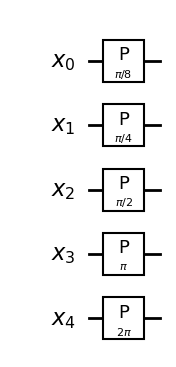

In [2]:
shors_alg.adder(2,15).draw(output="mpl", style="bw")

In [3]:
shors_alg.adder??

Signature: shors_alg.adder(a: int, N: int) -> qiskit.circuit.quantumcircuit.QuantumCircuit
Source:   
def adder(a: int, N: int) -> QuantumCircuit:
    """Returns the uncontrolled adder circuit.

    Parameters
    ----------
    a : int
        Positive integer strictly less than `N`
    N : int
        Positive integer, which Shor's algorithm factors

    Returns
    -------
    QuantumCircuit
        Unitary operator that takes in the state
            |phi(b)>_(n+1)
        and outputs the state
            |phi(a+b)>_(n+1)
    """
    # See Section 2.1 and Figure 3 of "Circuit for Shor's Algorithm
    # using 2n+3 qubits"

    # Must first "solve" for n, set up registers needed
    # Based off of cited paper, QC Bootcamp Problem Session 2's
    # implementation of Draper's adder circuit, and class lecture on
    # 22 May 2025

    # We utilize the corollary that relates the QFT, A_k (Draper),
    # and this (controlled) phase gate P_n(a) (phiADD(a))

    # "Solving" for n
    n = m

# Tests

In [4]:
# Set up for tests

a = 4
N = 15
x = 11

n = math.ceil(math.log2(N))

print(a, N, x, n)


4 15 11 4


## Adder

In [5]:
# Test adder
# Set b
# If we compose QFT, adder, IQFT, we should get a+b
b = 8

# Quantum registers
b_qr = QuantumRegister(n+1, name="b")

adder_test_qc = QuantumCircuit(b_qr, name="adder test")

1000
01000


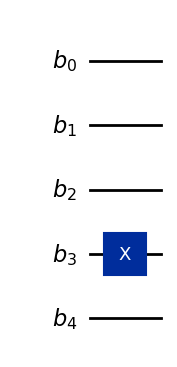

In [6]:
# Prepare state
b_bin = bin(b)[2:]
print(b_bin)

b_bin = b_bin.zfill(n+1)
print(b_bin)

for i, bit in enumerate(b_bin):
    if int(bit) == 1:
        adder_test_qc.x(b_qr[n-i])

adder_test_qc.draw("mpl")

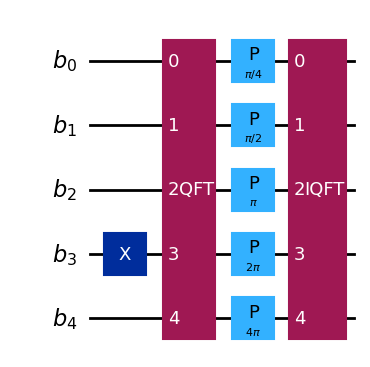

In [7]:
# Adder
adder_test_qc.compose(QFT(n+1).to_gate(), b_qr, inplace=True)
adder_test_qc.compose(shors_alg.adder(a,N), b_qr, inplace=True)
adder_test_qc.compose(QFT(n+1).inverse().to_gate(), b_qr, inplace=True)

adder_test_qc.draw("mpl")

In [8]:
# Measure output
adder_test_output = Statevector(adder_test_qc)
adder_test_prob_dict = adder_test_output.probabilities_dict()

# We should see a high probability for a+b
# The likeliest state is a+b in binary, padded with zeros
print(bin(a+b))
adder_test_predicted = (bin(a+b)[2:]).zfill(n+1)
print(adder_test_predicted)
adder_test_prob_dict.get(adder_test_predicted)

0b1100
01100


np.float64(0.9999999999999984)

## Subtractor

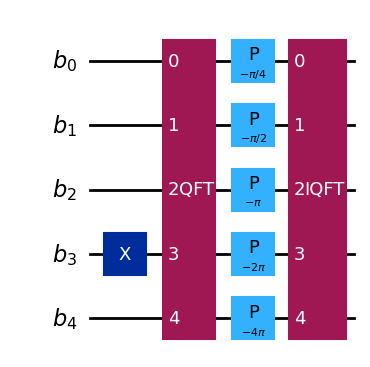

In [9]:
# Test subtractor
# If we compose QFT, subtractor, IQFT, we should get b-a

subtractor_test_qc = QuantumCircuit(b_qr, name="subtractor test")

# Prepare state

for i, bit in enumerate(b_bin):
    if int(bit) == 1:
        subtractor_test_qc.x(b_qr[n-i])

# Subtractor
subtractor_test_qc.compose(QFT(n+1).to_gate(), b_qr, inplace=True)
subtractor_test_qc.compose(shors_alg.subtractor(a,N), b_qr, inplace=True)
subtractor_test_qc.compose(QFT(n+1).inverse().to_gate(), b_qr, inplace=True)

subtractor_test_qc.draw("mpl")

In [10]:
# Measure output
subtractor_test_output = Statevector(subtractor_test_qc)
subtractor_test_prob_dict = subtractor_test_output.probabilities_dict()

# We should see a high probability for b-a
# The likeliest state is thus b-a in binary, padded with zeros
subtractor_test_predicted = str()
if b >= a:
    subtractor_test_predicted += (bin(b-a)[2:]).zfill(n+1)
else:
    subtractor_test_predicted += (bin(2**(n+1) - (a-b))[2:]).zfill(n+1)
print(subtractor_test_predicted)
subtractor_test_prob_dict.get(subtractor_test_predicted)

00100


np.float64(0.9999999999999982)

In [11]:
bin(-1)

'-0b1'

In [12]:
max(subtractor_test_prob_dict, key=subtractor_test_prob_dict.get)

np.str_('00100')

## Singly-controlled adder

### Control $c=1$

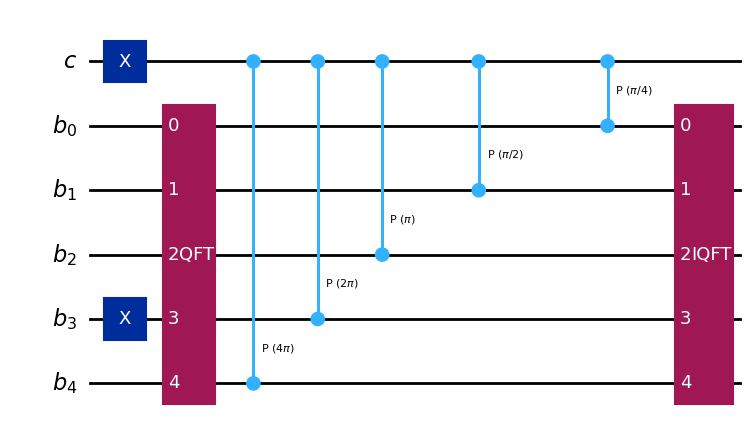

In [13]:
# Quantum registers
single_control_qr = QuantumRegister(1, name="c")
# already have b_qr

# Quantum circuit
c_adder_test1_qc = QuantumCircuit(single_control_qr, b_qr, name="c_adder test 1")

# Prepare control
c_adder_test1_qc.x(single_control_qr)

# Prepare state

for i, bit in enumerate(b_bin):
    if int(bit) == 1:
        c_adder_test1_qc.x(b_qr[n-i])

# Controlled adder
c_adder_test1_qc.compose(QFT(n+1).to_gate(), b_qr, inplace=True)
c_adder_test1_qc.compose(shors_alg.c_adder(a,N), qubits=[*single_control_qr, *b_qr], inplace=True)
c_adder_test1_qc.compose(QFT(n+1).inverse().to_gate(), b_qr, inplace=True)

c_adder_test1_qc.draw("mpl")

In [14]:
# Measure output
c_adder_test1_output = Statevector(c_adder_test1_qc)
c_adder_test1_prob_dict = c_adder_test1_output.probabilities_dict()

# We should see a high probability for a+b
# The likeliest state is thus a+b in binary, padded with zeros, plus control 1
c_adder_test1_predicted = (bin(a+b)[2:]).zfill(n+1) + str(1)
print(c_adder_test1_predicted)
c_adder_test1_prob_dict.get(c_adder_test1_predicted)

011001


np.float64(0.9999999999999984)

## Singly-controlled subtractor

In [15]:
#TODO

## Doubly-controlled adder

In [16]:
#TODO

## Doubly-controlled subtractor

In [17]:
#TODO

## Modular adder

### Controls $c_1 = c_2 = 1$

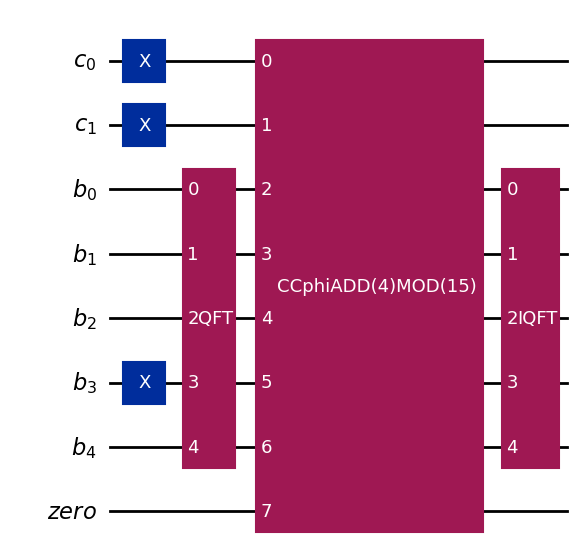

In [18]:
# Quantum registers
double_control_qr = QuantumRegister(2, name="c")
# already have b_qr
zero_qr = AncillaRegister(1, name="zero")

# Quantum circuit
modular_adder_test1_qc = QuantumCircuit(double_control_qr, b_qr, zero_qr, name="modular adder test 1")

# Prepare controls
modular_adder_test1_qc.x(double_control_qr[0])
modular_adder_test1_qc.x(double_control_qr[1])

# Prepare input state b
for i, bit in enumerate(b_bin):
    if int(bit) == 1:
        modular_adder_test1_qc.x(b_qr[n-i])

# Modular adder
modular_adder_test1_qc.compose(QFT(n+1).to_gate(), b_qr, inplace=True)
modular_adder_test1_qc.compose(shors_alg.cc_adder_mod(a,N).to_gate(), qubits=[*double_control_qr, *b_qr, *zero_qr], inplace=True)
modular_adder_test1_qc.compose(QFT(n+1).inverse().to_gate(), b_qr, inplace=True)

modular_adder_test1_qc.draw("mpl")

In [19]:
# Measure output
modular_adder_test1_qc_output = Statevector(modular_adder_test1_qc)
modular_adder_test1_qc_prob_dict = modular_adder_test1_qc_output.probabilities_dict()

# We should see a high probability for a+b
# The likeliest state is thus a+b in binary, padded with zeros, and controls 11
modular_adder_test1_predicted = (bin(a+b)[2:]).zfill(n+2) + str(11)
print(modular_adder_test1_predicted)
modular_adder_test1_qc_prob_dict.get(modular_adder_test1_predicted)

00110011


np.float64(0.9999999999999944)

In [20]:
max(modular_adder_test1_qc_prob_dict, key=modular_adder_test1_qc_prob_dict.get)

np.str_('00110011')

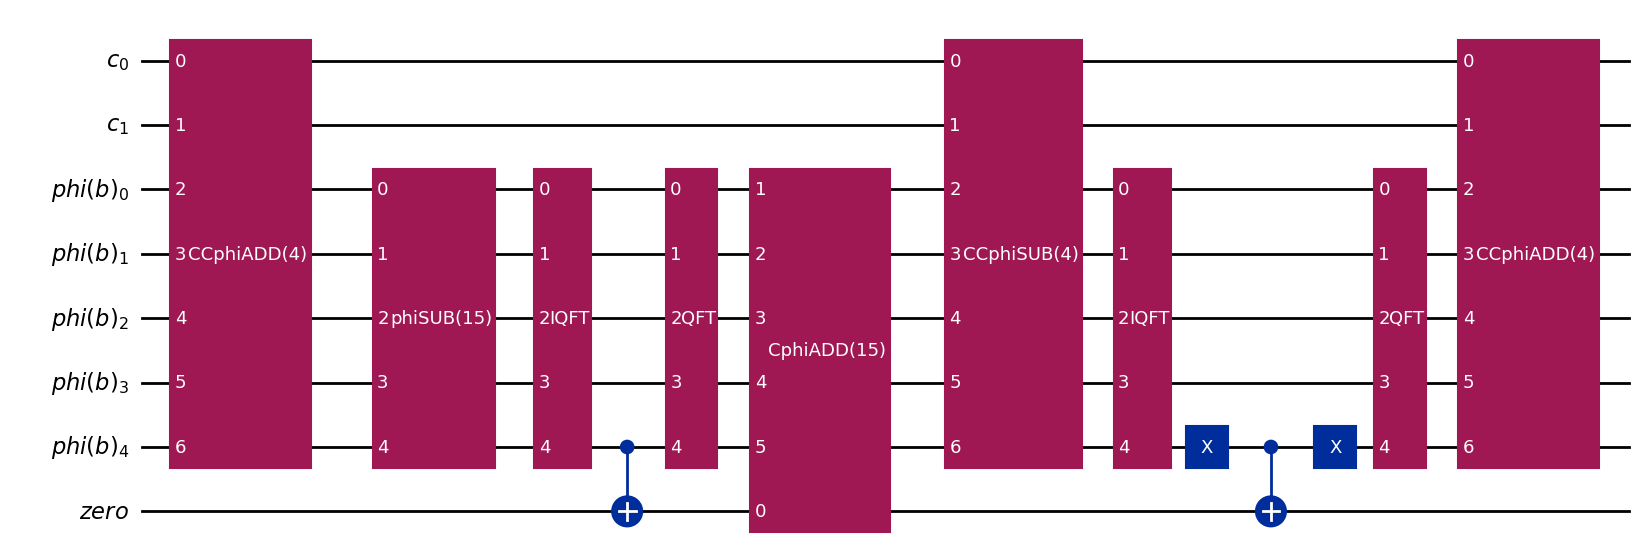

In [21]:
shors_alg.cc_adder_mod(a, N).draw("mpl")

## Inverse of modular adder

### Controls $c_1 = c_2 = 1$

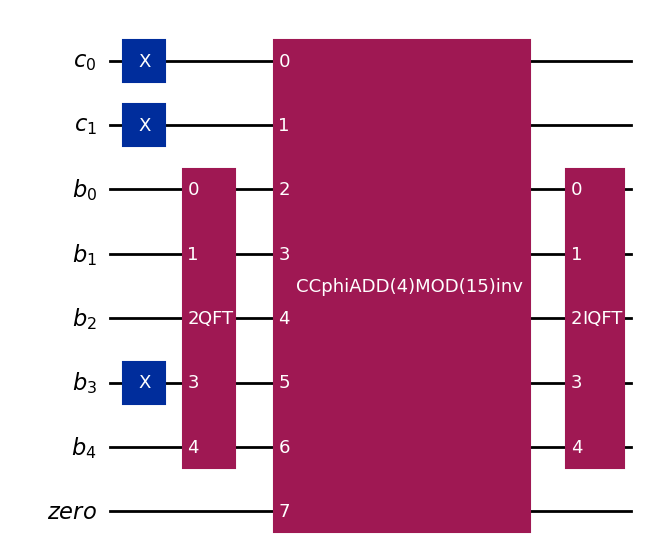

In [22]:
# Quantum circuit
modular_adder_inv_test1_qc = QuantumCircuit(double_control_qr, b_qr, zero_qr, name="modular adder inv test 1")

# Prepare controls
modular_adder_inv_test1_qc.x(double_control_qr[0])
modular_adder_inv_test1_qc.x(double_control_qr[1])

# Prepare input state b=3
# We should have b = 0011 in binary, so we prepare the state 1100
for i, bit in enumerate(b_bin):
    if int(bit) == 1:
        modular_adder_inv_test1_qc.x(b_qr[n-i])

# Modular adder inverse
modular_adder_inv_test1_qc.compose(QFT(n+1).to_gate(), b_qr, inplace=True)
modular_adder_inv_test1_qc.compose(shors_alg.cc_adder_mod_inv(a,N).to_gate(), qubits=[*double_control_qr, *b_qr, *zero_qr], inplace=True)
modular_adder_inv_test1_qc.compose(QFT(n+1).inverse().to_gate(), b_qr, inplace=True)

modular_adder_inv_test1_qc.draw("mpl")

In [23]:
# Measure output
modular_adder_inv_test1_output = Statevector(modular_adder_inv_test1_qc)
modular_adder_inv_test1_prob_dict = modular_adder_inv_test1_output.probabilities_dict()

# We should see a high probability for b-a mod N
# The likeliest state is thus b-a % N in binary, padded with zeros, and controls 11
modular_adder_inv_test1_predicted = (bin((b-a) % N)[2:]).zfill(n+2) + str(11)
print(modular_adder_inv_test1_predicted)
modular_adder_inv_test1_prob_dict.get(modular_adder_inv_test1_predicted)

00010011


np.float64(0.9999999999999949)

## Controlled multiplier

### Control $c=1$

1011


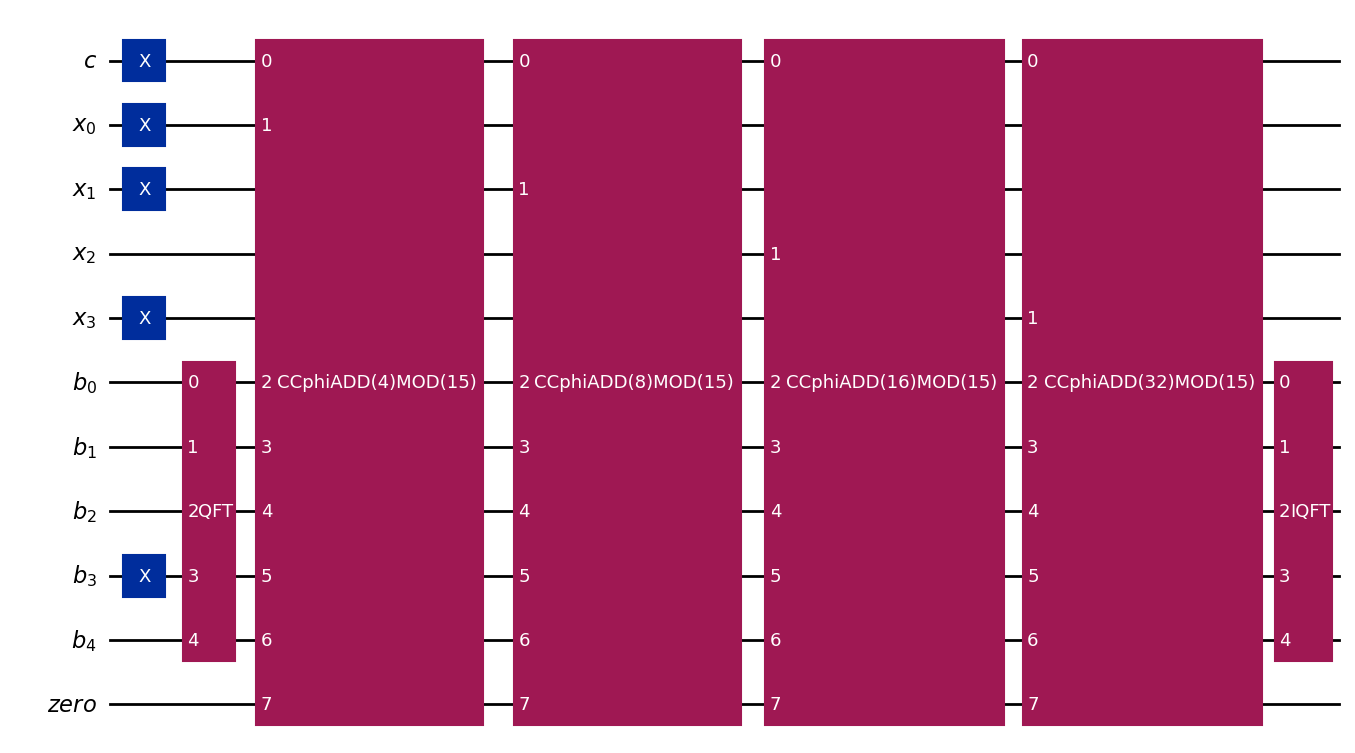

In [24]:
# Quantum registers
# single_control_qr
x_qr = QuantumRegister(n, name="x")
# b_qr
# zero_qr

# Quantum circuit
c_mult_test1_qc = QuantumCircuit(single_control_qr, x_qr, b_qr, zero_qr, name="c_mult test 1")

# Prepare control
c_mult_test1_qc.x(single_control_qr)

# Prepare x register
x_bin = bin(x)[2:]
x_bin = x_bin.zfill(n)
print(x_bin)
for i, bit in enumerate(x_bin):
    if int(bit) == 1:
        c_mult_test1_qc.x(x_qr[n-1-i])

# Prepare b register
for i, bit in enumerate(b_bin):
    if int(bit) == 1:
        c_mult_test1_qc.x(b_qr[n-i])

# CMULT(a)MOD(N)
c_mult_test1_qc.compose(shors_alg.c_mult_mod(a,N), qubits=[*single_control_qr, *x_qr, *b_qr, *zero_qr], inplace=True)

c_mult_test1_qc.draw("mpl")


In [25]:
# Measure output
c_mult_test1_output = Statevector(c_mult_test1_qc)
#print(c_mult_test1_output)
c_mult_test1_prob_dict = c_mult_test1_output.probabilities_dict()

# We should see a high probability for b+a*x mod N appearing in the b register
# The likeliest state is thus b+a*x % N in binary, padded with zeros, and control 1
c_mult_test1_predicted = (bin((b+a*x) % N)[2:]).zfill(n+2) + x_bin + str(1)
print(c_mult_test1_predicted)
c_mult_test1_prob_dict.get(c_mult_test1_predicted)

00011110111


np.float64(1.5432333851746562e-31)

In [26]:
print(b)
print(a)
print(x)
print(b+a*x)
print((b+a*x) % N)
print(bin((b+a*x) % N))

8
4
11
52
7
0b111


In [27]:
max(c_mult_test1_prob_dict, key=c_mult_test1_prob_dict.get)

np.str_('00010110111')

In [28]:
c_mult_test1_prob_dict.get(max(c_mult_test1_prob_dict, key=c_mult_test1_prob_dict.get))

np.float64(0.9999999999999813)

## Inverse of controlled multiplier

### Control $c=1$

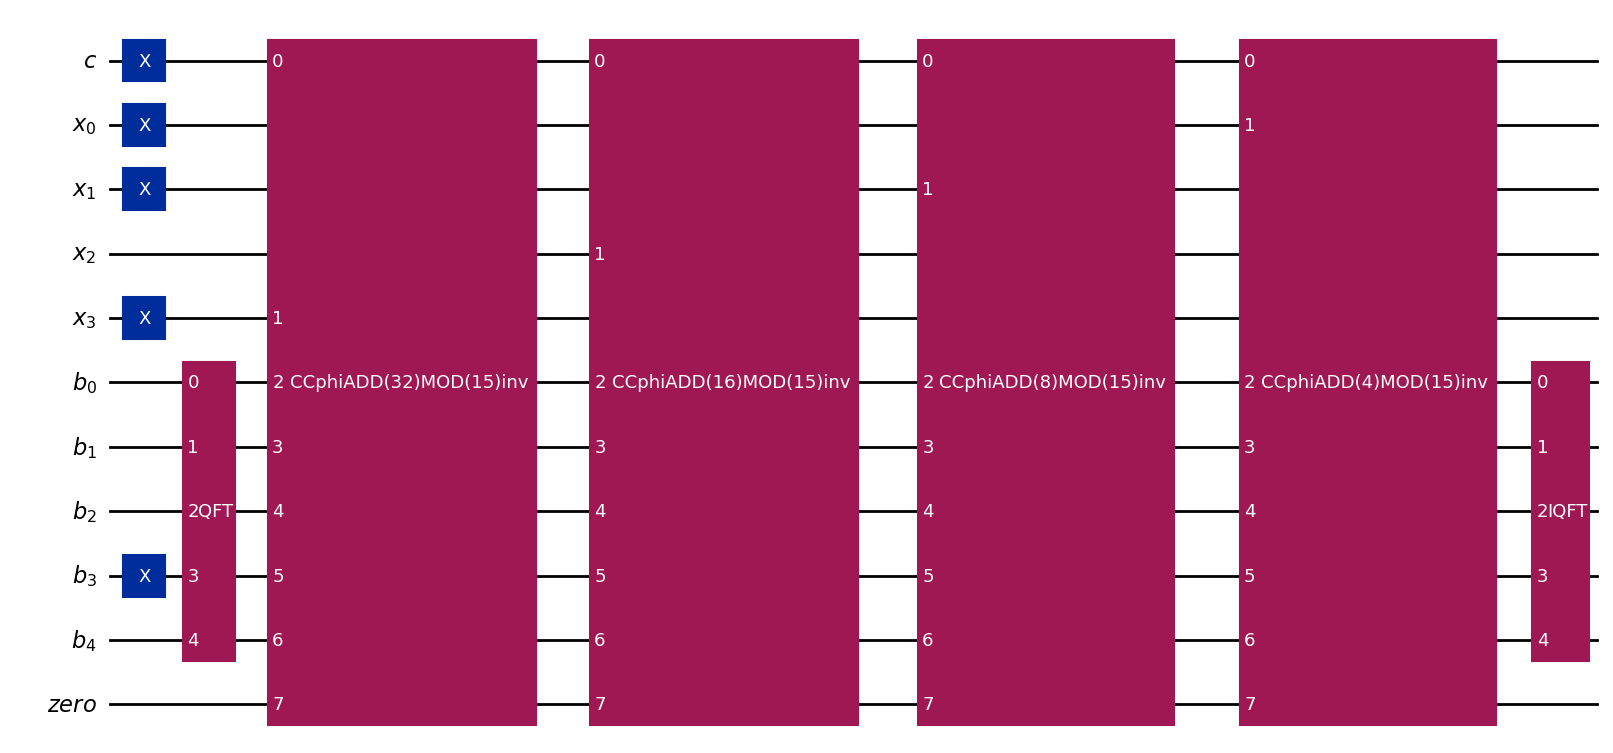

In [29]:
# Quantum circuit
c_mult_inv_test1_qc = QuantumCircuit(single_control_qr, x_qr, b_qr, zero_qr, name="c_mult_inv test 1")

# Prepare control
c_mult_inv_test1_qc.x(single_control_qr)

# Prepare x register
for i, bit in enumerate(x_bin):
    if int(bit) == 1:
        c_mult_inv_test1_qc.x(x_qr[n-1-i])

# Prepare b register
for i, bit in enumerate(b_bin):
    if int(bit) == 1:
        c_mult_inv_test1_qc.x(b_qr[n-i])

# CMULT(a)MOD(N)inv
c_mult_inv_test1_qc.compose(shors_alg.c_mult_mod_inv(a,N), qubits=[*single_control_qr, *x_qr, *b_qr, *zero_qr], inplace=True)

c_mult_inv_test1_qc.draw("mpl")

In [30]:
# Measure output
c_mult_inv_test1_output = Statevector(c_mult_inv_test1_qc)
c_mult_inv_test1_prob_dict = c_mult_inv_test1_output.probabilities_dict()

# We should see a high probability for b-a*x mod N appearing in the b register
# The likeliest state is thus b-a*x % N in binary, padded with zeros, and control 1
c_mult_inv_test1_predicted = (bin((b-a*x) % N)[2:]).zfill(n+2) + x_bin + str(1)
print(c_mult_inv_test1_predicted)
c_mult_inv_test1_prob_dict.get(c_mult_inv_test1_predicted)

00100110111


np.float64(8.510053846606408e-32)

In [31]:
max(c_mult_inv_test1_prob_dict, key=c_mult_inv_test1_prob_dict.get)

np.str_('00101110111')

## Oracle

### Control $c=1$

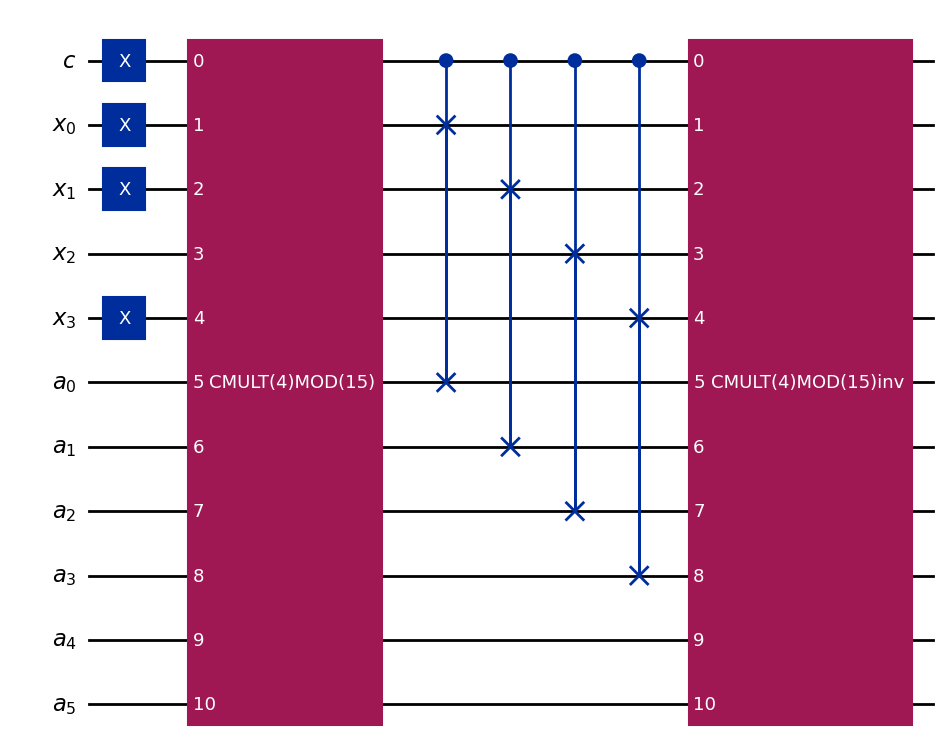

In [32]:
# Quantum registers
# single_control_qr
# x_qr
ancilla = AncillaRegister(n+2, name="a")

# Quantum circuit
oracle_test1_qc = QuantumCircuit(single_control_qr, x_qr, ancilla)

# Prepare control
oracle_test1_qc.x(single_control_qr)

# Prepare x register
for i, bit in enumerate(x_bin):
    if int(bit) == 1:
        oracle_test1_qc.x(x_qr[n-1-i])

# Oracle
oracle_test1_qc.compose(shors_alg.oracle(a,N), qubits=[*single_control_qr, *x_qr, *ancilla], inplace=True)

oracle_test1_qc.draw("mpl")

In [33]:
# Measure output
oracle_test1_output = Statevector(oracle_test1_qc)
oracle_test1_prob_dict = oracle_test1_output.probabilities_dict()

# We should see a high probability for a*x mod N appearing in the x register
# The likeliest state is thus a*x % N in binary, padded with zeros, and control 1
oracle_test1_predicted = (bin((a*x) % N)[2:]).zfill(2*n+2) + str(1)
print(oracle_test1_predicted)
oracle_test1_prob_dict.get(oracle_test1_predicted)

00000011101


np.float64(7.948206171256043e-62)

In [34]:
max(oracle_test1_prob_dict, key=oracle_test1_prob_dict.get)

np.str_('00101011001')

In [35]:
a_inv = pow(a,-1,N)
a_inv

4

In [36]:
a * a_inv % N

1